In [1]:
pip install fake_useragent

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import requests
import json
from fake_useragent import UserAgent
import time
import pandas as pd
import numpy as np
import math
import locale
import datetime
import os
from tqdm.auto import tqdm
from openai import OpenAI
import matplotlib.pyplot as plt

## 0. 相关方程

In [4]:
# 获取所有微博评论方程
def fetch_all(COOKIE_HEADER, BASE, params, max_pages=30):
  ua = UserAgent().random
  s = requests.Session()
  s.headers.update({
      "User-Agent": ua,
      "Accept": "application/json, text/plain, */*",
      "Referer": "https://weibo.com/",
      "Cookie": COOKIE_HEADER,
      "Connection": "keep-alive",
  })

  # Warm up: looks more like a browser flow and can set/refresh session cookies
  s.get("https://weibo.com/", timeout=15)

  # If XSRF-TOKEN exists as a cookie, mirror it in header (often helps)
  xsrf = s.cookies.get("XSRF-TOKEN")
  if xsrf:
      s.headers["X-XSRF-TOKEN"] = xsrf

  out = []

  for page in range(1, max_pages + 1):
      r = s.get(BASE, params=params, timeout=15)
      r.raise_for_status()
      j = r.json()

      if j.get("ok") == -100:
          raise RuntimeError("Login required (ok:-100): cookies expired / incomplete / mismatched.")

      data = j.get("data", [])
      out.extend(data)

      next_max_id = j.get("max_id", 0)
      print(f"page={page} got={len(data)} next_max_id={next_max_id}")

      # stop if stream ends
      if not data or not next_max_id:
          break

      params["max_id"] = next_max_id
      time.sleep(1)  #每次访问后休眠一秒

  return out

In [4]:
# 情感分析方程
def deepseek_sentiment_3class(
    df: pd.DataFrame,
    text_col: str = "comment",
    model: str = "deepseek-chat",
    rows_per_request: int = 50,
    max_retries: int = 5,
    sleep_base: float = 1.5,
) -> pd.DataFrame:
  texts = df[text_col].astype(str).fillna("").tolist()
  n = len(texts)

  labels = [None] * n
  confs  = [None] * n

  SYSTEM = """你是中文微博评论的情感分析器。
  你的任务是判断评论的整体情感倾向，只能输出以下三类之一：

  - POS：整体为正面（包括表扬、支持、送花、点赞、正向表情）
  - NEG：整体为负面（不满、批评、讽刺、抱怨）
  - MIXED：同时包含明显正面和负面，或态度矛盾

  规则：
  - 即使评论很短，只要语用上是支持或表扬，也可以判为 POS
  - 不要输出 NEU / UNKNOWN / 其他类别
  - 不要解释规则
  """

  for start in tqdm(range(0, n, rows_per_request), desc="DeepSeek sentiment (3-class)"):
      end = min(start + rows_per_request, n)
      batch = texts[start:end]

      payload = [{"i": start + j, "text": t} for j, t in enumerate(batch)]

      user_msg = (
          "请对以下评论逐条进行情感判断，只能输出严格 JSON。\n\n"
          "JSON 格式：\n"
          "{\n"
          '  "results": [\n'
          '    {"i": 0, "label": "POS|NEG|MIXED", "confidence": 0~1}, ...\n'
          "  ]\n"
          "}\n\n"
          f"评论列表：{json.dumps(payload, ensure_ascii=False)}"
      )

      for attempt in range(max_retries):
          try:
              resp = client.chat.completions.create(
                  model=model,
                  messages=[
                      {"role": "system", "content": SYSTEM},
                      {"role": "user", "content": user_msg},
                  ],
                  temperature=0,
                  response_format={"type": "json_object"},
              )

              data = json.loads(resp.choices[0].message.content)

              for r in data["results"]:
                  i = int(r["i"])
                  labels[i] = r["label"]
                  confs[i]  = float(r["confidence"])

              break

          except Exception:
              if attempt == max_retries - 1:
                  for i in range(start, end):
                      labels[i], confs[i] = "MIXED", 0.5
              else:
                  time.sleep(sleep_base * (2 ** attempt))

  return pd.DataFrame(
      {"sentiment": labels, "confidence": confs},
      index=df.index,
  )

In [5]:
#总结关键词方程
def summarize_keywords_with_examples(comments_df, n: int = 50, model: str = "deepseek-chat"):
  comments = (
      comments_df.head(n)["comment"]
      .astype(str)
      .fillna("")
      .tolist()
  )

  SYSTEM = """你是中文社交媒体评论分析助手。
  任务：从给定评论中提炼最重要的3个关键词，并为每个关键词挑选3条最能代表该关键词的原始评论（逐字引用）。
  要求：
  - 只输出 JSON（不要输出任何额外文字）
  - keywords 必须恰好 3 个
  - 每个 keyword 的 supporting_comments 必须恰好 3 条，且必须来自输入评论原文（逐字）
  - summary 用中文，不超过两句话
  - 关键词要尽量是“主题/实体/概念词”，避免过于泛化（如“感觉”“东西”）
  """

  user_msg = (
      "请从以下评论中提炼关键词并给出例句。\n"
      "输出严格 JSON，格式必须为：\n"
      "{\n"
      '  "keywords": [\n'
      '    {"keyword": "xxx", "supporting_comments": ["原始评论1","原始评论2","原始评论3"]},\n'
      '    {"keyword": "yyy", "supporting_comments": ["...","...","..."]},\n'
      '    {"keyword": "zzz", "supporting_comments": ["...","...","..."]}\n'
      "  ],\n"
      '  "summary": "两句话以内"\n'
      "}\n\n"
      "注意：supporting_comments 必须逐字来自输入评论，不要改写。\n\n"
      f"评论列表：{json.dumps(comments, ensure_ascii=False)}"
  )

  resp = client.chat.completions.create(
      model=model,
      messages=[
          {"role": "system", "content": SYSTEM},
          {"role": "user", "content": user_msg},
      ],
      temperature=0,
      response_format={"type": "json_object"},
  )

  return json.loads(resp.choices[0].message.content)

In [6]:
# 画总结图方程
def plot_sentiment(ax, df, title, sentiment_col="sentiment"):
  order = ["POS", "NEG", "MIXED"]
  counts = df[sentiment_col].value_counts().reindex(order).fillna(0).astype(int)
  total = counts.sum()

  if total == 0:
      pct = counts * 0.0
  else:
      pct = counts / total * 100.0

  x = np.arange(len(order))
  bars = ax.bar(x, counts.values)

  ax.set_xticks(x, order)
  ax.set_ylabel("Count")
  ax.set_title(title)

  for rect, p in zip(bars, pct.values):
      h = rect.get_height()
      ax.text(
          rect.get_x() + rect.get_width() / 2,
          h,
          f"{p:.1f}%",
          ha="center",
          va="bottom"
      )

  ymax = max(counts.max(), 1)
  ax.set_ylim(0, ymax * 1.20)

## 1. 获取微博的所有评论

In [7]:
# Web scrap the post
BASE = "https://weibo.com/ajax/statuses/buildComments"

params = {
    "flow": 1,
    "is_reload": 1,
    "id": "5263307886035659", #需要改
    "is_show_bulletin": 2,
    "is_mix": 0,
    "count": 20,
    "uid": "1742666164",
    "fetch_level": 0,
    "max_id": 0,
}

# Cookie
sub = '_2A25EjtKWDeThGeBM7lcQ9SvJzD-IHXVn4mperDV8PUNbmtANLWj9kW9NRKjw1AV-t0I9Cp-NBqOgxOncpDBBH40_'
subp = '0033WrSXqPxfM725Ws9jqgMF55529P9D9W5TlCjAaenMyBGd_bR545Pq5JpX5KzhUgL.FoqESK-pSK-fS0e2dJLoIpjLxK-L1hnL1KnLxKqLBozL1h2LxKqL1--L1-et'
token = 'YvXSrykPgkaP83IB_C4RChby'
wbpsess = 'KKjJ5y6hgYOYNKH6i7xu70aSkNrC9xSiSqIO7s6fQCLY7lO7EPP0x1QEL_B25vAb_ZbcfuXYaJWPMPBOngmaLVjTwt_HFe_X01JdpWW1TQpTA1e0FLlY7zLe36jw4_U2tsZ-U5OIpQRKr4tpfZ1NlA=='
alf = '02_1773285318'

COOKIE_HEADER = f"SUB={sub}; SUBP={subp}; XSRF-TOKEN={token}; WBPSESS={wbpsess}; ALF={alf};"

comments = fetch_all(COOKIE_HEADER=COOKIE_HEADER, BASE=BASE, params=params)
print("total comments returned (including repeats):", len(comments))

page=1 got=19 next_max_id=5263458876524743
page=2 got=19 next_max_id=5263387489471806
page=3 got=19 next_max_id=5263350686550028
page=4 got=18 next_max_id=5263334527471390
page=5 got=19 next_max_id=5263321072404828
page=6 got=20 next_max_id=5263317917505823
page=7 got=19 next_max_id=5263313143599171
page=8 got=17 next_max_id=0
total comments returned (including repeats): 150


In [8]:
# 提取有用信息
comments_arr = [c.get('text_raw') for c in comments]
comments_time = [c.get('created_at') for c in comments]
comments_like = [c.get('like_counts') for c in comments]

# 整合成DataFrame
comments_df = pd.DataFrame({
    'posted_time': pd.Series(comments_time),
    'comment': pd.Series(comments_arr),
    'like_count': pd.Series(comments_like)
})

# format时间
comments_df['posted_time'] = pd.to_datetime(
    comments_df["posted_time"],
    format="%a %b %d %H:%M:%S %z %Y",
    errors="raise"
).dt.tz_localize(None)

## 2. 用DeepSeek来判断评论好坏

In [9]:
# 这是我的个人API密钥，不可泄露
os.environ["DEEPSEEK_API_KEY"] = "sk-26e3bd6a00974081a25dc993e91f2a09"

client = OpenAI(
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url="https://api.deepseek.com"
)

In [10]:
# 让DeepSeek判断评论好坏
evaled_df = deepseek_sentiment_3class(
    comments_df,
    text_col="comment",
    rows_per_request=50,
)

df_final = comments_df.join(evaled_df)

DeepSeek sentiment (3-class):   0%|          | 0/3 [00:00<?, ?it/s]

In [11]:
# 让DeepSeek给出近50条评论的关键词/热词
keyword_result = summarize_keywords_with_examples(comments_df, n=50)

## 3. 总结

### 3.1 近50条与所有评论好评占比

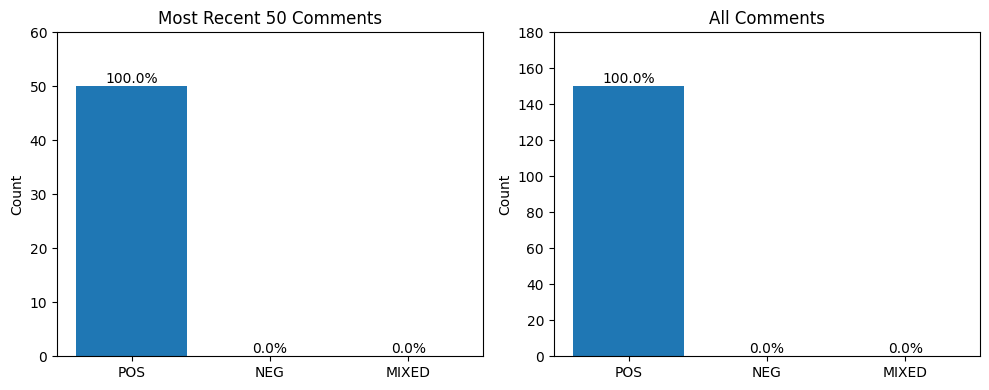

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

plot_sentiment(
    axes[0],
    df_final.head(50),
    "Most Recent 50 Comments"
)

plot_sentiment(
    axes[1],
    df_final,
    "All Comments"
)

plt.tight_layout()
plt.show()

### 3.2 重复出现的评论及其频率

In [13]:
dup_rows = df_final[df_final.duplicated(subset="comment", keep=False)]
dup_comment_summary = (
    dup_rows
    .groupby('comment', as_index=False)
    .agg(
        freq=('comment', 'size'),
        sentiment=('sentiment', 'first')
    )
).sort_values(by='freq', ascending=False)

dup_comment_summary

,comment,freq,sentiment
8,感谢邀请,8,POS
1,[赢牛奶]感谢兰蔻邀请，期待常华森！,3,POS
5,感谢兰蔻邀请[求关注][求关注]期待以后更多合作～,3,POS
0,[求关注],2,POS
3,感谢兰蔻的邀请 期待未来能与常华森有更多的合作机会,2,POS
2,[送花花],2,POS
6,感谢兰蔻邀请，期待常华森！,2,POS
4,感谢兰蔻的邀请 期待未来能与常华森有更多的合作机会[给你小心心],2,POS
7,感谢兰蔻邀请，期待更多合作[爱慕],2,POS
9,感谢邀请 期待更多合作,2,POS


### 3.3 近50条评论的关键信息总结：

In [14]:
for item in keyword_result["keywords"]:
    print("关键词:", item["keyword"])
    for c in item["supporting_comments"]:
        print("  -", c)

print("\n总结:", keyword_result["summary"])

关键词: 兰蔻
  - 感谢兰蔻邀请
  - 感谢兰蔻的邀请，期待以后合作[爱你]
  - 感谢@兰蔻LANCOME 邀请，期待更多合作
关键词: 常华森
  - @常华森 好帅，期待未来更多合作[打call]
  - 啊啊啊啊啊啊啊啊常华森
  - 常华森的脸果然适合高清观看[么么哒]
关键词: 合作
  - 感谢邀请 期待更多合作
  - 感谢邀请，期待和兰蔻多多合作呀[打call]
  - 期待更多与常华森的合作[么么哒]

总结: 评论主要围绕兰蔻品牌邀请、演员常华森的参与以及未来合作机会展开，表达了粉丝的感谢和期待。
